# Data Preprocessing

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import joblib
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer

In [24]:
df = pd.read_csv(r"D:\Ameng\Data Science Project\heart-failure-prediction\data\heart_failure_clinical_records_dataset.csv")
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


## Stratified Split

In [25]:
X = df.drop("DEATH_EVENT", axis=1)
y = df["DEATH_EVENT"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [26]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTarget distribution (train):")
print(y_train.value_counts(normalize=True))
print("\nTarget distribution (test):")
print(y_test.value_counts(normalize=True))

Train shape: (239, 12)
Test shape: (60, 12)

Target distribution (train):
DEATH_EVENT
0    0.677824
1    0.322176
Name: proportion, dtype: float64

Target distribution (test):
DEATH_EVENT
0    0.683333
1    0.316667
Name: proportion, dtype: float64


## Pipeline

In [27]:
def build_preprocessor(include_time=True):
    log_cols = ["creatinine_phosphokinase", "serum_creatinine", "platelets"]
    scale_cols = ["age", "ejection_fraction", "serum_sodium"]
    bin_cols = ["anaemia", "diabetes", "high_blood_pressure", "sex", "smoking"]
    if include_time:
        log_cols.append("time")
    return ColumnTransformer([
        ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one"), log_cols),
        ("scale", StandardScaler(), scale_cols),
        ("pass", "passthrough", bin_cols),
    ])

preprocessor = build_preprocessor(include_time=True)

## Fit and Transform

In [28]:
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

## Numerical Verification

In [29]:
feature_names = preprocessor.get_feature_names_out()

X_train_prep_df = pd.DataFrame(X_train_prep, columns=feature_names)
X_test_prep_df = pd.DataFrame(X_test_prep, columns=feature_names)

print("Shape:", X_train_prep_df.shape, X_test_prep_df.shape)
print("NaN total:", X_train_prep_df.isnull().sum().sum())

Shape: (239, 12) (60, 12)
NaN total: 0


In [30]:
# check scaled features
print("Scaled features (mean, std):")
print(X_train_prep_df[["scale__age", "scale__ejection_fraction", "scale__serum_sodium"]].agg(["mean", "std"]).round(3))


Scaled features (mean, std):
      scale__age  scale__ejection_fraction  scale__serum_sodium
mean       0.000                     0.000                0.000
std        1.002                     1.002                1.002


In [31]:
# check binary features (0/1)
print("Binary features:")
print(X_train_prep_df[["pass__anaemia", "pass__smoking"]].describe().loc[["min", "max"]])

Binary features:
     pass__anaemia  pass__smoking
min            0.0            0.0
max            1.0            1.0


## Visual Verification

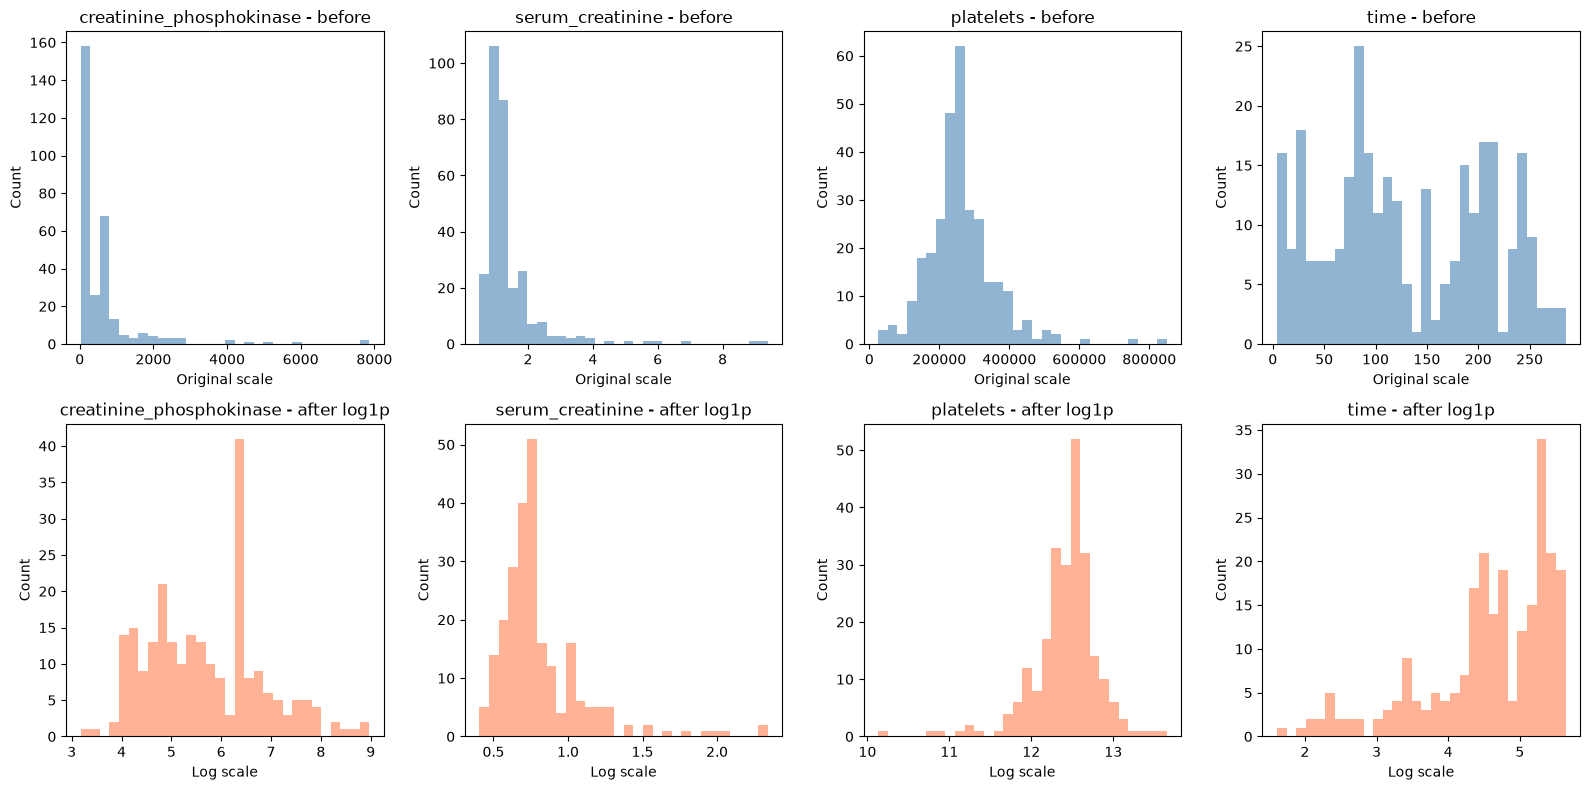

In [33]:
LOG_COLS = ["creatinine_phosphokinase", "serum_creatinine", "platelets", "time"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, feat in enumerate(LOG_COLS):
    axes[0, i].hist(df[feat], bins=30, alpha=0.6, color="steelblue")
    axes[0, i].set_title(f"{feat} - before")
    axes[0, i].set_xlabel("Original scale")
    axes[0, i].set_ylabel("Count")  

    axes[1, i].hist(X_train_prep_df[f"log__{feat}"], bins=30, alpha=0.6, color="coral")
    axes[1, i].set_title(f"{feat} - after log1p")
    axes[1, i].set_xlabel("Log scale")
    axes[1, i].set_ylabel("Count")

plt.tight_layout()
plt.show()

## Export Data and Pipeline

In [37]:
PROCESSED_DIR = r"D:\Ameng\Data Science Project\heart-failure-prediction\data\processed"
os.makedirs(PROCESSED_DIR, exist_ok=True)

X_train_prep_df.to_csv(os.path.join(PROCESSED_DIR, "X_train.csv"), index=False)
X_test_prep_df.to_csv(os.path.join(PROCESSED_DIR, "X_test.csv"), index=False)
y_train.to_csv(os.path.join(PROCESSED_DIR, "y_train.csv"), index=False)
y_test.to_csv(os.path.join(PROCESSED_DIR, "y_test.csv"), index=False)

In [38]:
joblib.dump(preprocessor, os.path.join(PROCESSED_DIR, "preprocessor.joblib"))
print("Saved to:", PROCESSED_DIR)

Saved to: D:\Ameng\Data Science Project\heart-failure-prediction\data\processed
